In [14]:
import os
import autoslo.utils.paths as pu
import matplotlib.pyplot as plt
import numpy as np
from autoslo.workload_execution.trace import Trace

In [13]:
runs_df = pu.RunLocator.get_runs_df()
subset_df = runs_df[(runs_df['blueprint_name'] == 'single_8') & (runs_df['workload_name'].str.startswith('tpcds'))].copy()
subset_df['pct_heavy'] = subset_df['workload_name'].apply(lambda x: int(x.split('_')[-2].replace('pctheavy', '')))
subset_df['mean_interarrivals'] = subset_df['workload_name'].apply(lambda x: int(x.split('_')[-1].replace('meaninterarrivals', '')))
subset_df

,run_id,workload_name,num_queries,scale_factor,schema_name,blueprint_name,query_router_name,maxconns,closed_loop,pct_heavy,mean_interarrivals
16,1763240707,tpcds_99templates_00pctheavy_120meaninterarrivals,34,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,0,120
19,1763244884,tpcds_99templates_00pctheavy_60meaninterarrivals,71,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,0,60
22,1763249132,tpcds_99templates_00pctheavy_30meaninterarrivals,127,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,0,30
25,1763253312,tpcds_99templates_00pctheavy_10meaninterarrivals,352,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,0,10
27,1763257627,tpcds_99templates_10pctheavy_120meaninterarrivals,35,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,10,120
30,1763261816,tpcds_99templates_10pctheavy_60meaninterarrivals,71,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,10,60
33,1763266158,tpcds_99templates_10pctheavy_30meaninterarrivals,125,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,10,30
36,1763270759,tpcds_99templates_10pctheavy_10meaninterarrivals,349,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,10,10
39,1763277547,tpcds_99templates_25pctheavy_120meaninterarrivals,34,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,25,120
41,1763282030,tpcds_99templates_25pctheavy_60meaninterarrivals,63,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False,25,60


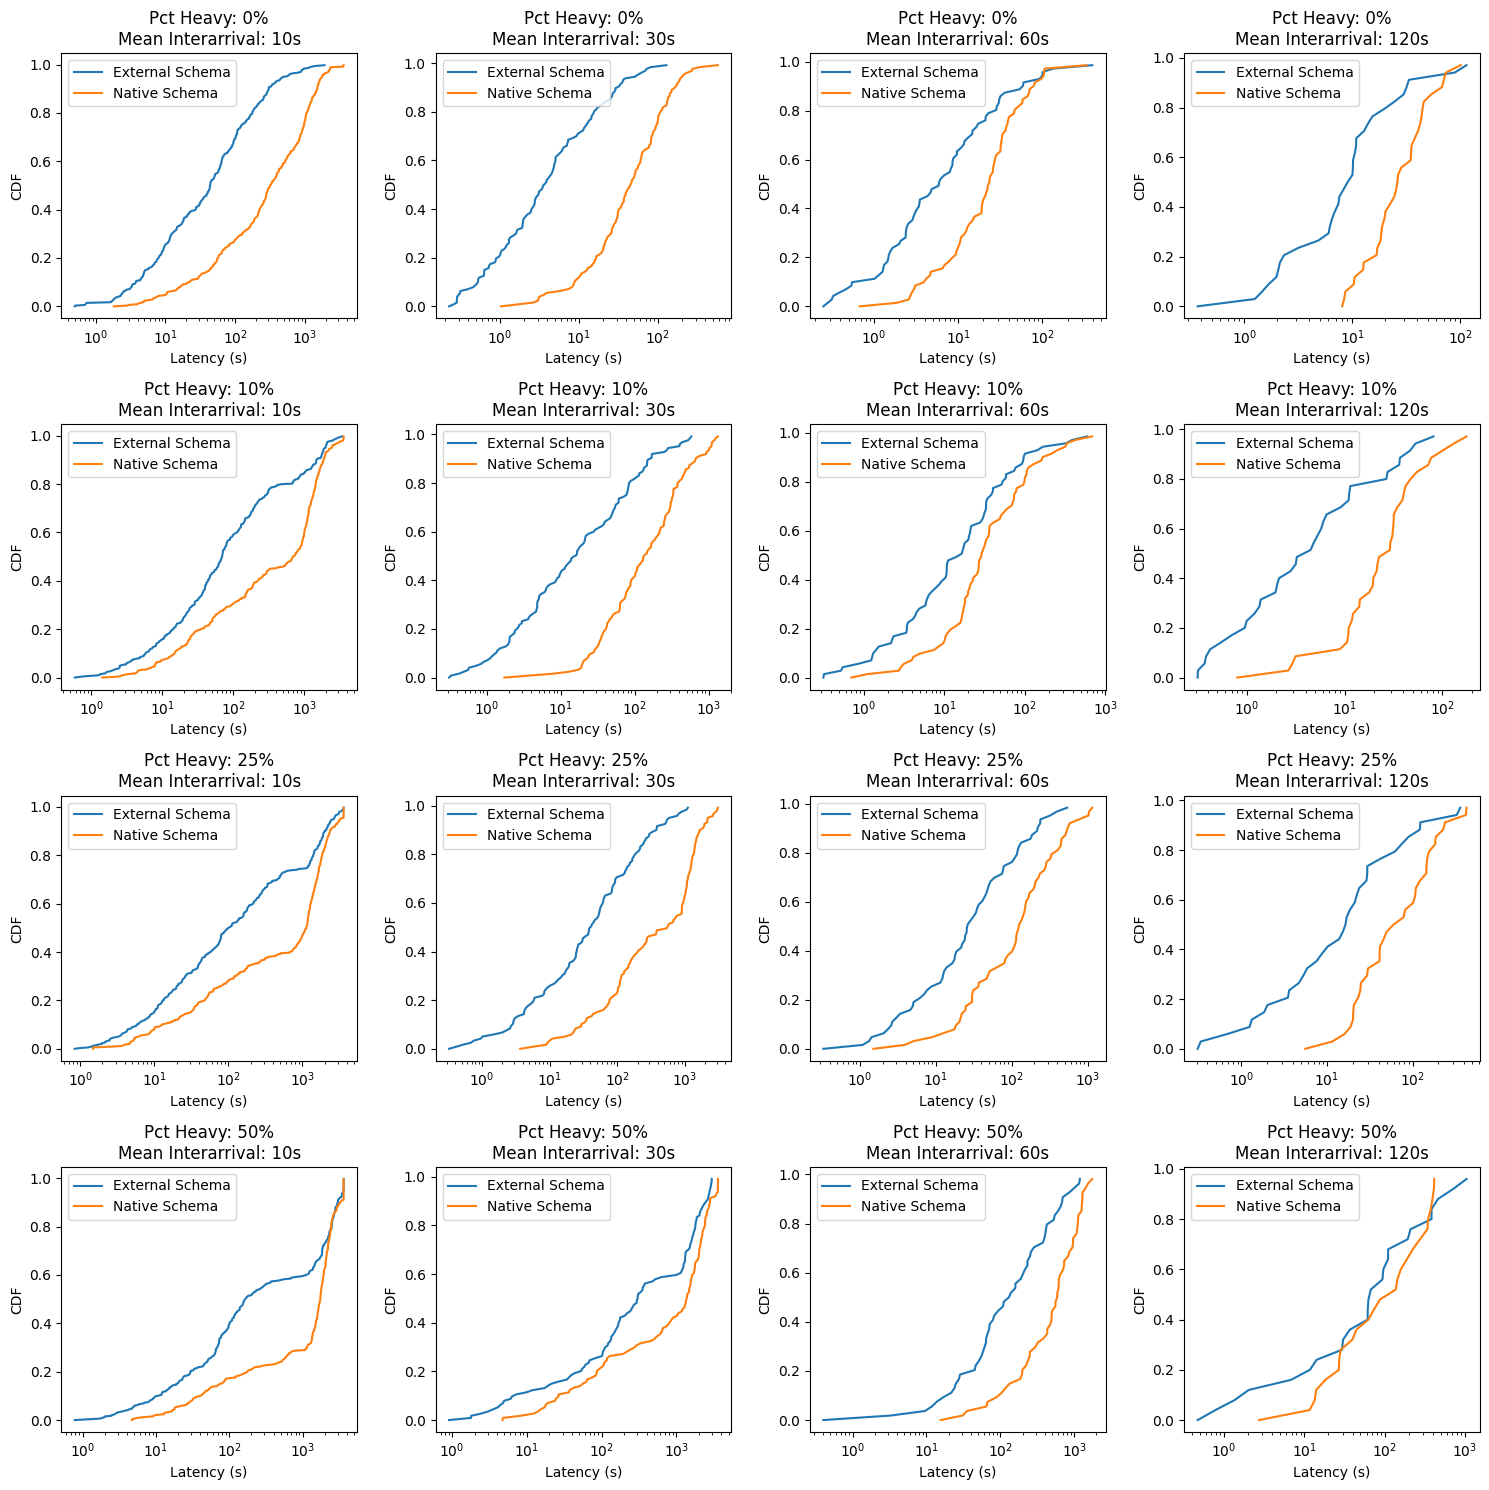

In [15]:
fig, axes = plt.subplots(
    nrows=4, ncols=4, figsize=(15, 15), sharex=False, sharey=False
)

pct_heavy_options = [0, 10, 25, 50]
mean_interarrival_options = [10, 30, 60, 120]


for i, pct_heavy in enumerate(pct_heavy_options):
    for j, mean_interarrival in enumerate(mean_interarrival_options):
        ax = axes[i, j]

        def get_and_plot_latencies(schema_name, label):
            run_id = subset_df[
                (subset_df["pct_heavy"] == pct_heavy)
                & (subset_df["mean_interarrivals"] == mean_interarrival)
                & (subset_df["schema_name"] == schema_name)
            ]["run_id"].iloc[0]
            trace = Trace(run_id)
            latencies = trace.latencies_s.sort_values().reset_index(drop=True)
            ax.plot(latencies, latencies.index / len(latencies), label=label)
            ax.set_xlabel("Latency (s)")
            ax.set_ylabel("CDF")


        get_and_plot_latencies("ext_tpcds1000", "External Schema")
        get_and_plot_latencies("tpcds1000", "Native Schema")

        ax.legend()
        ax.set_title(
            f"Pct Heavy: {pct_heavy}%\nMean Interarrival: {mean_interarrival}s"
        )
        ax.set_xscale("log")

plt.tight_layout()
plt.show()

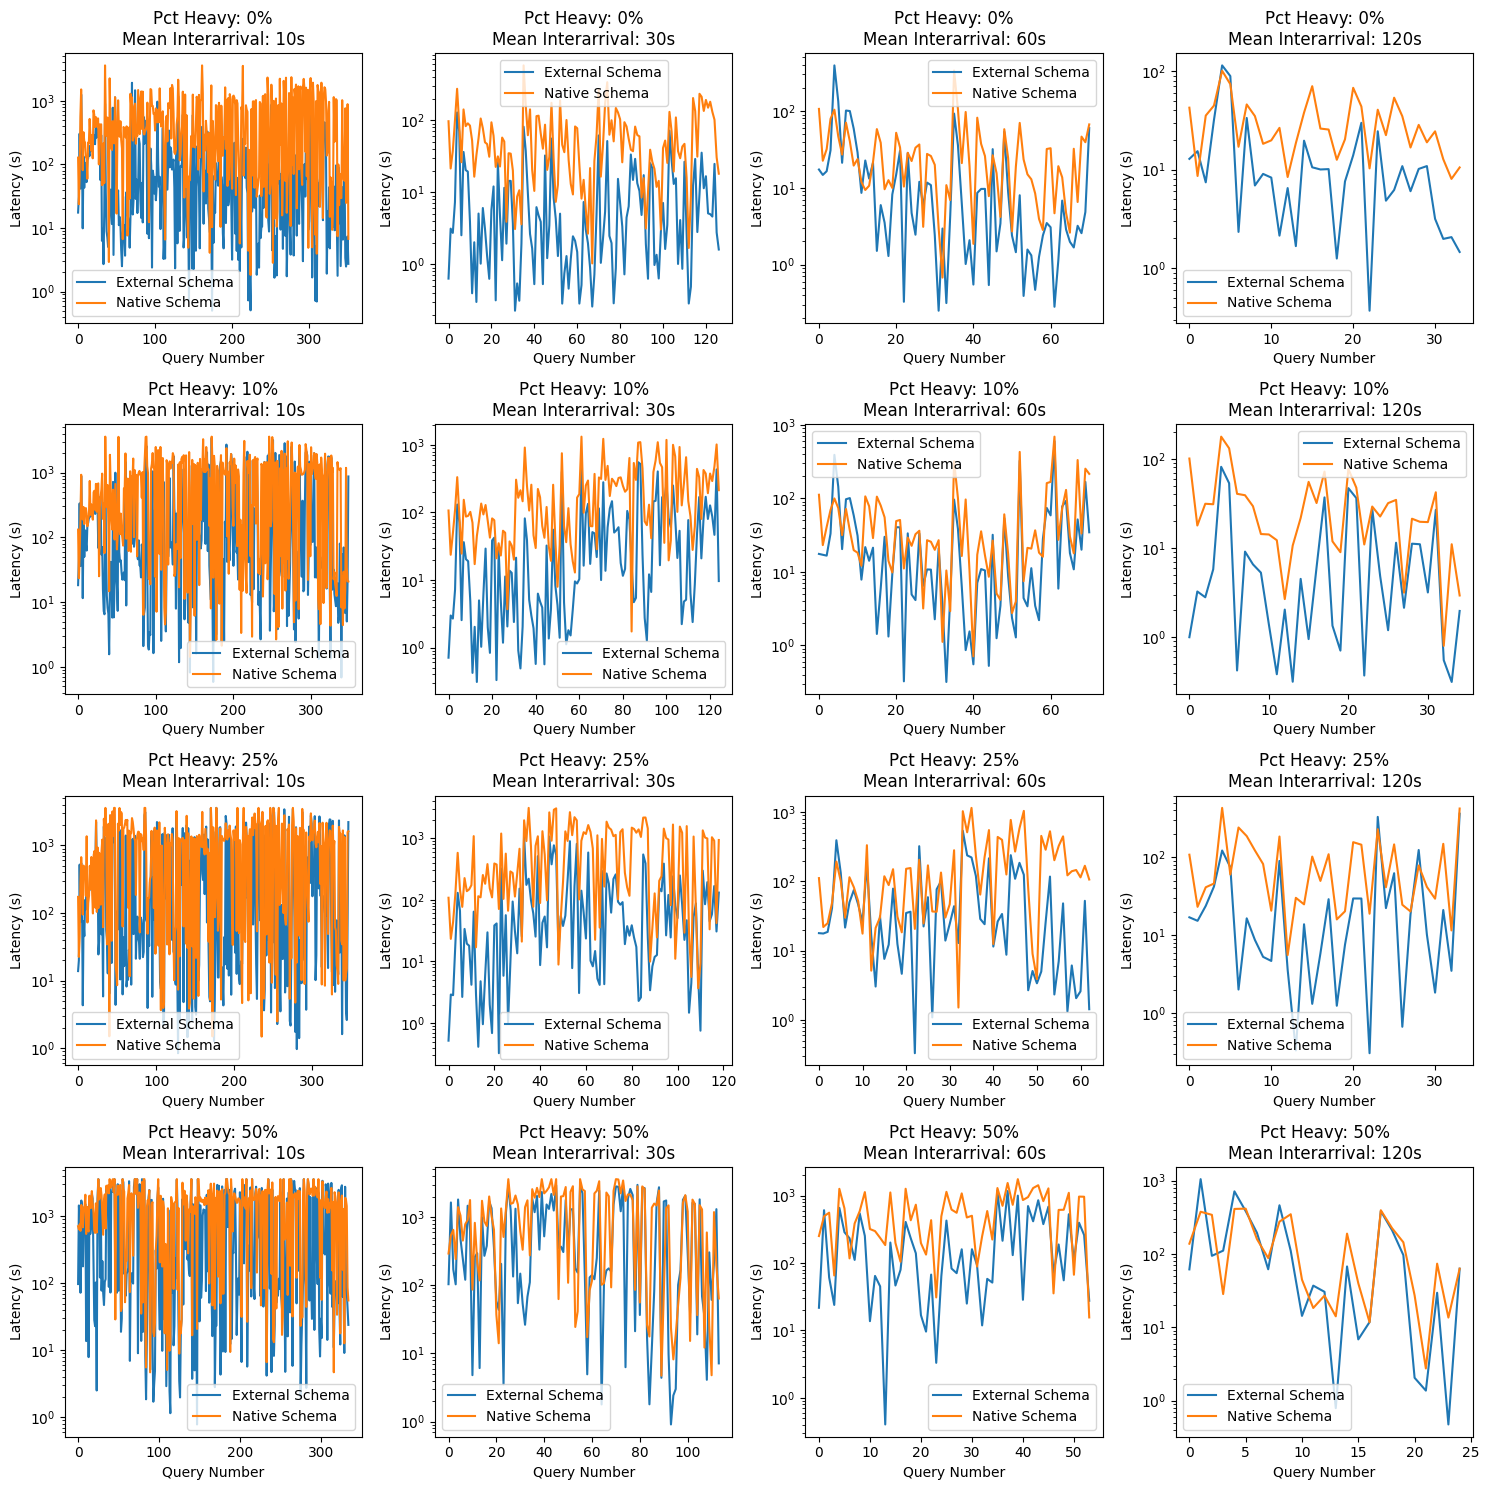

In [17]:
fig, axes = plt.subplots(
    nrows=4, ncols=4, figsize=(15, 15), sharex=False, sharey=False
)

pct_heavy_options = [0, 10, 25, 50]
mean_interarrival_options = [10, 30, 60, 120]


for i, pct_heavy in enumerate(pct_heavy_options):
    for j, mean_interarrival in enumerate(mean_interarrival_options):
        ax = axes[i, j]

        def get_and_plot_latencies(schema_name, label):
            run_id = subset_df[
                (subset_df["pct_heavy"] == pct_heavy)
                & (subset_df["mean_interarrivals"] == mean_interarrival)
                & (subset_df["schema_name"] == schema_name)
            ]["run_id"].iloc[0]
            trace = Trace(run_id)
            latencies = trace.latencies_s.reset_index(drop=True)
            ax.plot(latencies.index, latencies, label=label)
            ax.set_xlabel("Query Number")
            ax.set_ylabel("Latency (s)")


        get_and_plot_latencies("ext_tpcds1000", "External Schema")
        get_and_plot_latencies("tpcds1000", "Native Schema")

        ax.legend()
        ax.set_title(
            f"Pct Heavy: {pct_heavy}%\nMean Interarrival: {mean_interarrival}s"
        )
        ax.set_yscale("log")

plt.tight_layout()
plt.show()